In [ ]:
from datasets import load_from_disk, Dataset
import torch

/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
original_ds = load_from_disk("../../../datasets/gaussian_noise_dataset")

In [ ]:
original_ds

Dataset({
    features: ['image', 'captions'],
    num_rows: 1000
})

In [ ]:
print(torch.cuda.device_count())
print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])

2
['NVIDIA TITAN RTX', 'NVIDIA TITAN RTX']


In [11]:
# from torchvision import models, transforms

# # Load ResNet model and set to eval mode
# resnet = models.resnet50(pretrained=True)
# resnet.eval()

# # Define image preprocessing
# preprocess = transforms.Compose([
#     transforms.Lambda(lambda img: img.convert("RGB")),
#     transforms.Resize(256),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     ),
# ])

# def image_to_features(example):
#     # Convert PIL image to tensor and preprocess
#     image = example["image"]
#     input_tensor = preprocess(image).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")
#     resnet.to("cuda" if torch.cuda.is_available() else "cpu")
#     with torch.no_grad():
#         features = resnet(input_tensor)
#     return {"image_tensor": features.cpu().squeeze().numpy()}

In [ ]:
from torchvision import models, transforms
import numpy as np
from PIL import Image
# Load ResNet model and set to eval mode
resnet = models.resnet152(pretrained=True)
resnet.eval()

# Define image preprocessing
preprocess = transforms.Compose([
    transforms.Lambda(lambda img: Image.fromarray(
        ((np.array(img) - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) * 255)
        .astype(np.uint8)
        .transpose(1, 2, 0)
    )),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

def image_to_features(example):
    # Convert PIL image to tensor and preprocess
    image = example["image"]
    input_tensor = preprocess(image).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")
    resnet.to("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        features = resnet(input_tensor)
    return {"image_tensor": features.cpu().squeeze().numpy()}

In [ ]:
preprocess = transforms.Compose([
    transforms.Lambda(lambda img: Image.fromarray(
        ((np.array(img) - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) * 255)
        .astype(np.uint8)
        .transpose(1, 2, 0)
    )),
    transforms.Lambda(lambda img: img.convert("RGB"))])

preprocess

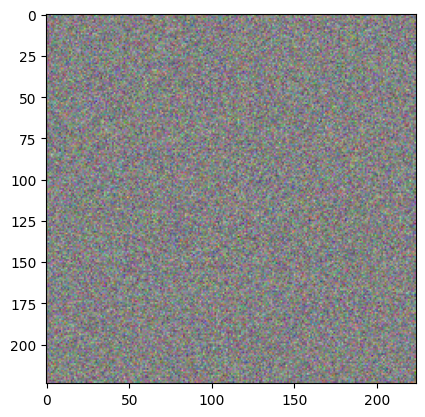

In [ ]:
from matplotlib import pyplot as plt
for i in original_ds.select(range(10))['image']: 
    plt.imshow(preprocess(i))
plt.show()

In [ ]:
# import os

# print(os.cpu_count())

In [12]:
# new_ds = original_ds.map(
#     lambda example: {
#         "captions": example["captions"],
#         "features": torch.tensor(image_to_features(example)["image_tensor"])
#     },
#     remove_columns=[col for col in original_ds.column_names if col not in ["captions"]],
#     # num_proc=24
# )

In [ ]:
new_ds = original_ds.map(
    lambda example: {
        "captions": example["captions"],
        "features": torch.tensor(image_to_features(example)["image_tensor"])
    },
    remove_columns=[col for col in original_ds.column_names if col not in ["captions"]],
    # num_proc=24
)

Map: 100%|██████████| 1000/1000 [00:36<00:00, 27.69 examples/s]


In [ ]:
new_ds.select(range(10))

Dataset({
    features: ['captions', 'features'],
    num_rows: 10
})

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,

    "axes.titlesize": 11,
    "axes.labelsize": 10,

    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    "legend.fontsize": 9,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.7,

    "lines.linewidth": 1.5,

    "savefig.bbox": "tight",
})

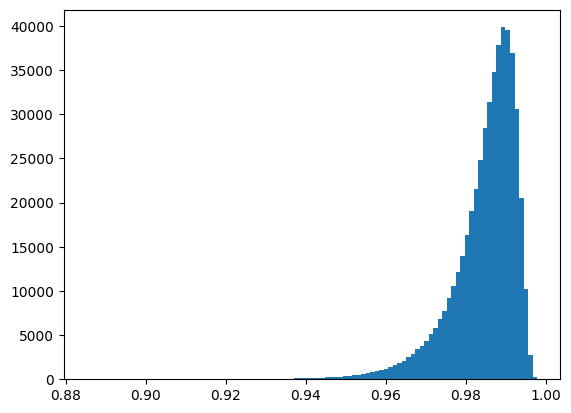

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.stack(new_ds.select(range(1000))["features"])

X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
sim_matrix = X_norm @ X_norm.T

sims = sim_matrix[np.triu_indices(len(X), k=1)]

plt.hist(sims, bins=100)
plt.show()

In [27]:
len(new_ds['features'][0])

1000

In [13]:
new_ds.save_to_disk("../../../datasets/noise_features_resnet_152")

Saving the dataset (1/1 shards): 100%|██████████| 1000/1000 [00:00<00:00, 12556.52 examples/s]


In [15]:
len(new_ds[0]['features'])

1000

In [ ]:
ds = load_from_disk("../../../datasets/coco_val_features")
ds

In [ ]:
ds[0]